In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# СЧИТЫВАЕМ данные

In [2]:
# orders_xlsx = pd.read_excel('/Users/vladislavlipkin/Documents/PycharmProjects/Simulate/final_python_samokat/data/orders.xlsx') # MACOS
orders_xlsx = pd.read_excel(r'C:\Users\Incognitus\Documents\git_hub\Simulate\final_python_samokat\data\orders.xlsx') # WIN

In [3]:
# products_xlsx = pd.read_excel('/Users/vladislavlipkin/Documents/PycharmProjects/Simulate/final_python_samokat/data/products.xlsx') # MACOS
products_xlsx = pd.read_excel(r'C:\Users\Incognitus\Documents\git_hub\Simulate\final_python_samokat\data\products.xlsx') # WIN

# и что же там ?

In [4]:
orders_xlsx.head(5)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130


In [5]:
products_xlsx.head(5)

,product_id,level1,level2,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...
1,2,Мучные кондитерские изделия,Мучные кондитерские изделия,Печенье Бодрость
2,3,Мясная гастрономия,"Сосиски, сардельки",Сосиски Стародворье
3,4,Чай,Черный чай,Чай Азерчай
4,5,Безалкогольные напитки,Соковая продукция,Морс Valio


# Описание таблиц

## Таблица products

| Колонка       | Описание                    |
|---------------|-----------------------------|
| product_id    | id товара                   |
| level1        | категория                   |
| level2        | подкатегория                |
| name          | наименование товара         |

## Таблица orders

| Колонка        | Описание                         |
|----------------|----------------------------------|
| order_id       | номер чека                       |
| accepted_at    | дата и время чека                |
| product_id     | id товара                        |
| quantity       | кол-во товара в чеке             |
| regular_price  | регулярная цена                  |
| price          | текущая цена                     |
| cost_price     | закупочная цена                  |

# TASKS

# -

# 1. Самая ходовая товарная группа

## Задание
По какой категории товаров продано больше всего позиций?

## Требования
1. Подкрепите ответ таблицей, в которой рассчитано количество проданных штук товара в каждой товарной категории.
2. Дополнительно постройте на основании этой таблицы barchart.
3. Проверьте, чтобы все подписи на графике выглядели читаемо и понятно.
4. График должен быть сходу понятен стороннему наблюдателю.

In [6]:
merge_table = pd.merge(
    orders_xlsx
    , products_xlsx
    , on='product_id'
    , how='left'
)

In [7]:
merge_table.head(3)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан


In [8]:
agg_count_category = merge_table.groupby('level1').agg(
    quantity_of_products = ('quantity', 'sum')
).reset_index()

result_quantity_of_products = agg_count_category.sort_values('quantity_of_products', ascending=False).reset_index().head(5)
result_quantity_of_products

,index,level1,quantity_of_products
0,1,Безалкогольные напитки,534
1,11,Молочная продукция,483
2,19,Свежие овощи,262
3,10,Кулинария,250
4,0,Бакалея,239


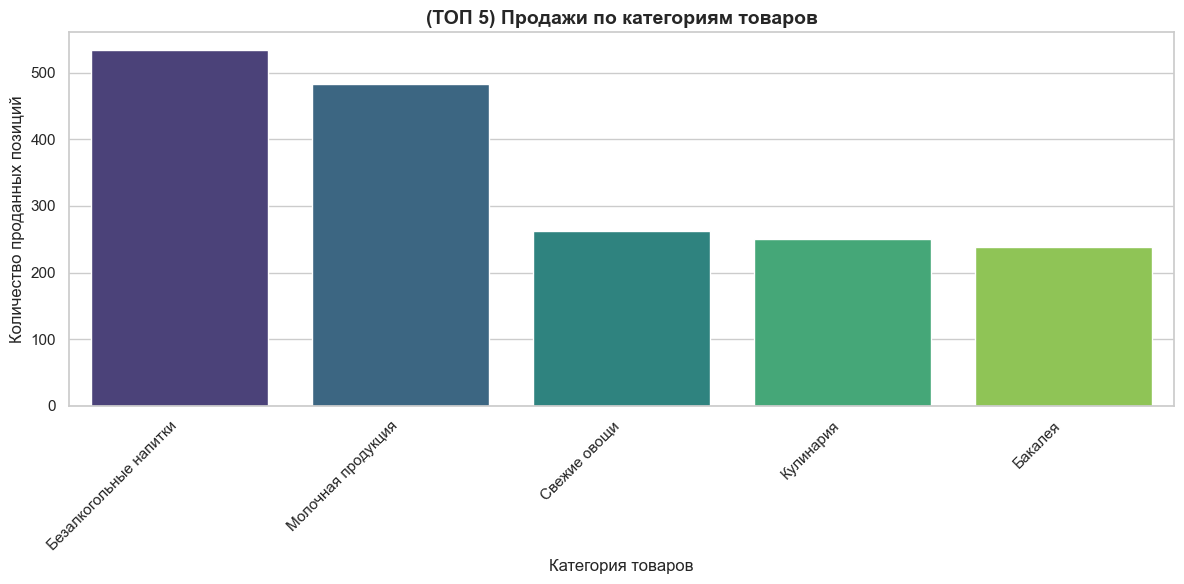

In [9]:
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(x='level1', y='quantity_of_products', data=result_quantity_of_products, palette='viridis')
plt.xlabel('Категория товаров', fontsize=12)
plt.ylabel('Количество проданных позиций', fontsize=12)
plt.title('(ТОП 5) Продажи по категориям товаров', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# -

# 2. Распределение продаж по подкатегориям

## Задание
Оцените распределение количества проданных позиций в каждой товарной категории (level1) по подкатегориям (level2). Проиллюстрируйте свой результат расчетной таблицей.

In [10]:
merge_table.head(1)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан


In [11]:
agg_count_subcategory = merge_table.groupby(['level1', 'level2']).agg(
    quantity_of_subcategory = ('quantity', 'sum')
).reset_index()

result_quantity_of_subcategory = agg_count_subcategory.sort_values(
    ['quantity_of_subcategory'], 
    ascending=[False]
).reset_index(drop=True)

result_quantity_of_subcategory.head(10)

,level1,level2,quantity_of_subcategory
0,Безалкогольные напитки,Напитки,252
1,Кулинария,Готовые блюда,248
2,Хлеб и хлебобулочные изделия,Хлеб и хлебобулочные изделия,218
3,Снэки,Снэки соленые,180
4,Безалкогольные напитки,Воды питьевые,162
5,Свежие овощи,"Корнеплоды, зелень и прочие овощи",157
6,Молочная продукция,Молоко и сливки,147
7,Молочная продукция,Молочно-десертные продукты,116
8,Свежие фрукты,"Цитрусовые, семечковые и прочие плоды",108
9,Молочная продукция,Кисломолочные традиционные продукты,106


# -

# Найти средний чек в заданную дату

## Задание
Какой средний чек был 13.01.2022?

In [12]:
# создадим столбец с датой , и приведем в строку
merge_table['date'] = merge_table['accepted_at'].dt.date.astype(str)
# сделаем общую сумму по чеку с учетом количества
merge_table['total_price'] = merge_table['price'] * merge_table['quantity']
merge_table.head(3)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name,date,total_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,2022-01-13,169
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,2022-01-13,169
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,2022-01-13,169


In [13]:
filter_time = '2022-01-13'
jan13_avg_check = merge_table.query('date == @filter_time')

In [14]:
print(f'средний чек по заданой дате {filter_time}: -- {round(jan13_avg_check['total_price'].mean(), 2)} --')

средний чек по заданой дате 2022-01-13: -- 149.9 --


# -

# Доля промо в заданной категории

## Описание задачи
Когда товар продается по промо-акции, его базовая цена не совпадает с фактической ценой.

## Задание
1. Посчитать, какую долю от общих продаж категории **Сыры** занимают промо (в штуках)
2. Построить пайчарт, который это проиллюстрирует
3. На графике должны быть видны группы, соответствующие доли и понятные подписи к ним

In [15]:
cheese_filter = 'Сыры'
cheese_table = merge_table.query('level1 == @cheese_filter')
cheese_table.head(3)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name,date,total_price
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130,Сыры,Мягкие сыры,Сыр Самокат,2022-01-13,219
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130,Сыры,Мягкие сыры,Сыр Самокат,2022-01-13,219
5,1517416615,2022-01-13 10:39:06,22199,1,219,219,130,Сыры,Мягкие сыры,Сыр Самокат,2022-01-13,219


In [16]:
promo_cheese = cheese_table.query('regular_price != price')
promo_cheese.head(3)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name,date,total_price
121,1517667466,2022-01-13 15:28:48,9385,2,152,129,77,Сыры,Твердые сычужные сыры,Сыр Cheese Gallery,2022-01-13,258
122,1517632967,2022-01-13 19:05:35,9385,1,152,129,77,Сыры,Твердые сычужные сыры,Сыр Cheese Gallery,2022-01-13,129
123,1517503071,2022-01-13 13:37:17,9385,1,152,129,77,Сыры,Твердые сычужные сыры,Сыр Cheese Gallery,2022-01-13,129


In [17]:
result_share = promo_cheese['quantity'].sum() / cheese_table['quantity'].sum() * 100.0
result_share

np.float64(30.701754385964914)

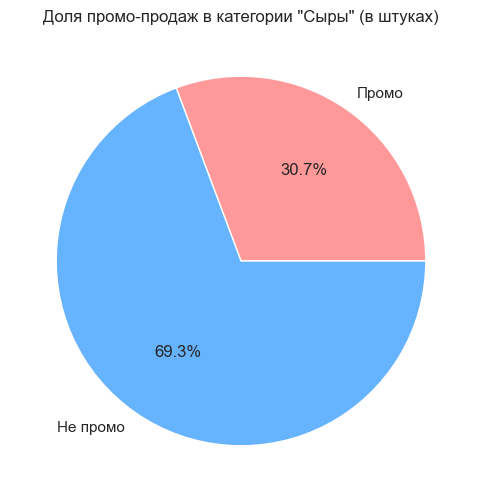

In [18]:
promo_qty = promo_cheese['quantity'].sum()
non_promo_qty = cheese_table['quantity'].sum() - promo_qty

plt.figure(figsize=(6,6))
plt.pie([promo_qty, non_promo_qty], 
        labels=['Промо', 'Не промо'], 
        autopct='%1.1f%%', 
        colors=['#ff9999', '#66b3ff'])
plt.title('Доля промо-продаж в категории "Сыры" (в штуках)')
plt.show()

# -

# Посчитать маржу по категориям

Нужно посчитать маржу:

- В рублях
- В %

Сделать это нужно по всем категориям level1 и отобразить с помощью 2 горизонтальных барчартов. Все подписи должны быть читаемыми и понятными.

In [19]:
merge_table.head(3)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name,date,total_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,2022-01-13,169
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,2022-01-13,169
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,2022-01-13,169


In [20]:
merge_table['cost_total_price'] = merge_table['cost_price'] * merge_table['quantity']
merge_table.head(3)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name,date,total_price,cost_total_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,2022-01-13,169,74
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,2022-01-13,169,74
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,2022-01-13,169,74


In [33]:
margin_rub_by_category = merge_table.groupby('level1').agg(
    total_revenue = ('total_price', 'sum'),
    total_cost = ('cost_total_price', 'sum')
).reset_index()

# margin in RUB
margin_rub_by_category['margin_rub'] = margin_rub_by_category['total_revenue'] - margin_rub_by_category['total_cost']
# margin in PERCENT
margin_rub_by_category['percent_margin'] = (margin_rub_by_category['total_revenue'] - margin_rub_by_category['total_cost']) / margin_rub_by_category['total_revenue'] * 100.0

result_margin = margin_rub_by_category.loc[:, ['level1', 'percent_margin', 'margin_rub']].sort_values(['percent_margin', 'margin_rub'], ascending=[False, False]).reset_index(drop=True)
result_margin

,level1,percent_margin,margin_rub
0,"Кофе, какао",51.828706,5059
1,Специальное питание,50.731707,208
2,Замороженная продукция,47.264920,13099
3,Чай,45.672852,2929
4,Мучные кондитерские изделия,45.188435,6283
5,Кулинария,45.181195,18452
6,Безалкогольные напитки,44.186349,20373
7,Снэки,42.630244,9582
8,Хлеб и хлебобулочные изделия,42.454496,6251
9,Кондитерские изделия,42.447282,5918


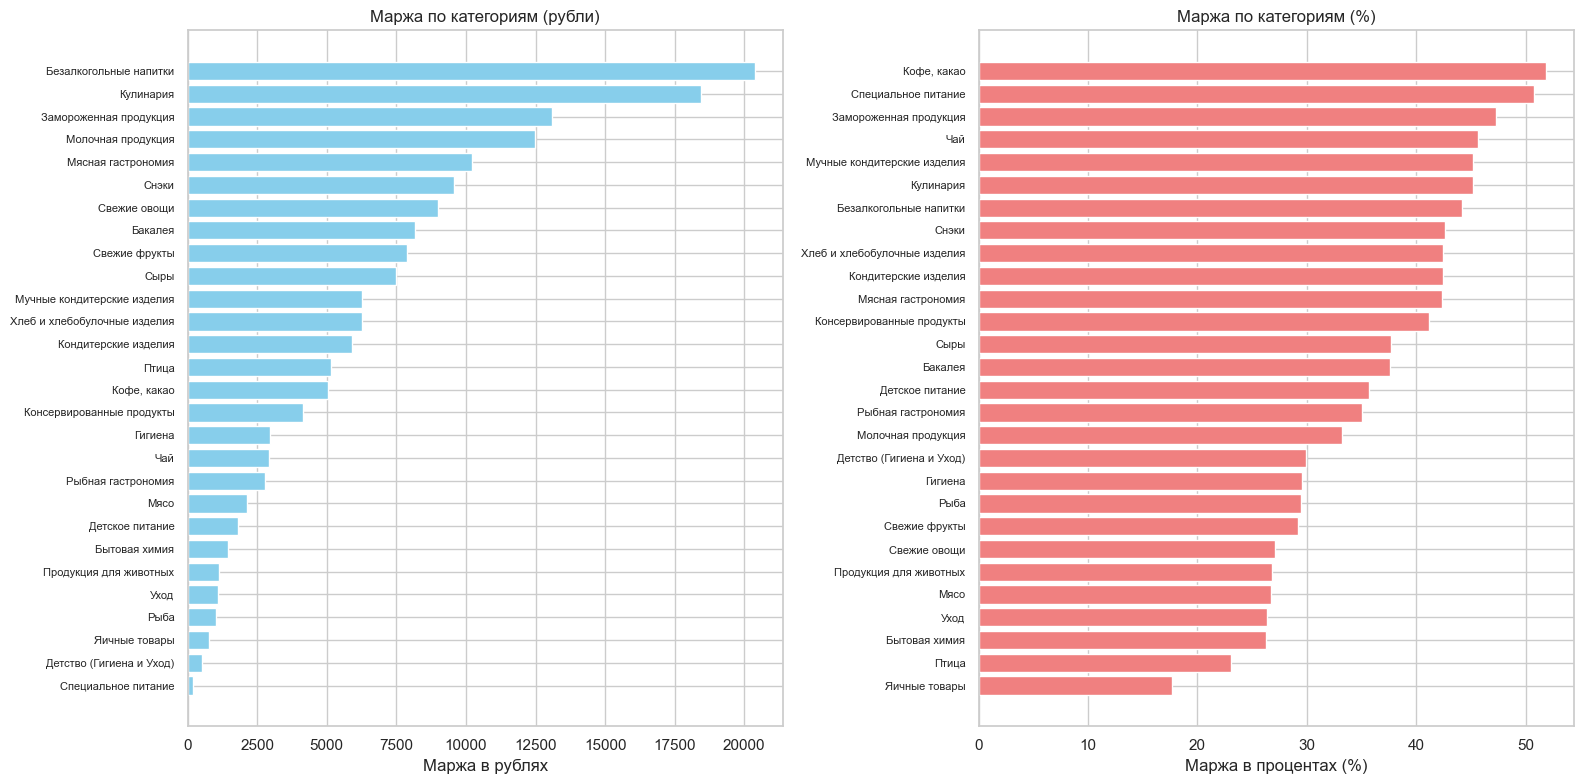

In [78]:
# Сортировка перед построением
result_margin_sorted_rub = result_margin.sort_values('margin_rub', ascending=True)
result_margin_sorted_pct = result_margin.sort_values('percent_margin', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Горизонтальный барчарт для маржи в рублях
ax1.barh(result_margin_sorted_rub['level1'], result_margin_sorted_rub['margin_rub'], color='skyblue')
ax1.set_xlabel('Маржа в рублях')
ax1.set_title('Маржа по категориям (рубли)')
ax1.tick_params(axis='y', labelsize=8)

# Горизонтальный барчарт для маржи в процентах
ax2.barh(result_margin_sorted_pct['level1'], result_margin_sorted_pct['percent_margin'], color='lightcoral')
ax2.set_xlabel('Маржа в процентах (%)')
ax2.set_title('Маржа по категориям (%)')
ax2.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

# -

# ABC анализ

## Задание

Сделайте ABC-анализ продаж по количеству

Сделайте ABC-анализ по сумме продаж

Сделайте новый столбец, в котором будет итоговая группа на основании двух анализов. Например: A C.

## Важно

- Проводить ABC-анализ по **подкатегориям (level2)**, а не по отдельным товарам
- Имеющихся данных за небольшой период недостаточно для качественного анализа на уровне товаров
- Количество товаров слишком велико, что может исказить результаты
- ABC-анализ по подкатегориям даст более адекватную и интерпретируемую картину

In [35]:
merge_table.head(3)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name,date,total_price,cost_total_price,percent_marginality
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,2022-01-13,169,74,56.213018
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,2022-01-13,169,74,56.213018
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,2022-01-13,169,74,56.213018


In [40]:
# общее количество товаров по всем категориям
total_quantity = merge_table['quantity'].sum()
total_quantity

np.int64(4105)

In [39]:
# общая сумма всех проданых товаров по всем категориям
total_sum = merge_table['total_price'].sum()
total_sum

np.int64(498107)

In [59]:
# агрегируем количество по подкатегориям
quantity_by_category = merge_table.groupby('level2').agg(
    sum_quantity_by_subcategory = ('quantity', 'sum')
).sort_values(by='sum_quantity_by_subcategory', ascending=False)

# доля от общего количества
quantity_by_category['share_percent_quantity'] = round(quantity_by_category['sum_quantity_by_subcategory'] / total_quantity * 100.0, 2)
# кумулятивная сумма
quantity_by_category['cumsum_quantity'] = quantity_by_category['share_percent_quantity'].cumsum()

In [60]:
# ABC function

def abc_counter(row):
    if row <= 80:
        return 'A'
    elif row <= 95:
        return 'B'
    elif row > 95:
        return 'C'   

In [61]:
quantity_by_category['ABC_quantity'] = quantity_by_category['cumsum_quantity'].apply(abc_counter)

In [63]:
# агрегируем сумму по подкатегориям
sum_by_category = merge_table.groupby('level2').agg(
    sum_by_subcategory = ('total_price', 'sum')
).sort_values(by='sum_by_subcategory', ascending=False)

# доля от общего количества
sum_by_category['share_percent_sum'] = round(sum_by_category['sum_by_subcategory'] / total_sum * 100.0, 2)
# кумулятивная сумма
sum_by_category['cumsum_sum'] = sum_by_category['share_percent_sum'].cumsum()

In [65]:
sum_by_category['ABC_sum'] = sum_by_category['cumsum_sum'].apply(abc_counter)

In [77]:
merge_abc_quantity_and_sum = pd.merge(
    quantity_by_category
    , sum_by_category
    , on='level2'
    , how='inner'
).reset_index()
merge_abc_quantity_and_sum['ABC_quantity_sum'] = merge_abc_quantity_and_sum['ABC_quantity'] + merge_abc_quantity_and_sum['ABC_sum']
result_abc = merge_abc_quantity_and_sum.loc[:, ['level2', 'ABC_quantity_sum']].sort_values(by='ABC_quantity_sum')
result_abc.columns = ['subcategory', 'ABC_quantity_sum']
result_abc.head(50)

,subcategory,ABC_quantity_sum
0,Напитки,AA
21,Не молочное детское питание,AA
22,Твердые сычужные сыры,AA
24,Бумажная продукция,AA
26,Яйцо куриное,AA
27,Воды минеральные,AA
30,Консервы овощные и грибные,AA
31,"Сосиски, сардельки",AA
32,"Крупы, бобовые",AA
33,Мясо животных охлажденное,AA
